# Binary Skin Cancer Classification with Fine-Tuning
## Neural Networks — Final Project

---

### Description

This project implements and compares three deep neural network architectures
using **fine-tuning** for binary classification of skin lesions
(malignant vs. benign), using the **ISIC 2024 SLICE-3D Permissive** dataset.

| Feature              | Detail                                           |
|----------------------|--------------------------------------------------|
| **Dataset**          | ISIC 2024 — SLICE-3D Permissive (CC-BY 4.0)     |
| **Images**           | ~200,000 skin lesion crops (~128×128 px)         |
| **Task**             | Binary classification (malignant vs. benign)     |
| **Class imbalance**  | ~99.87 % benign / ~0.13 % malignant              |
| **Primary metric**   | AUC-ROC (ISIC standard)                          |

| Model            | Type                | Parameters |
|------------------|---------------------|------------|
| ResNet-50        | Classic CNN         | 25.6 M     |
| EfficientNetV2-S | Optimized CNN       | 21.5 M     |
| ViT-B/16         | Vision Transformer  | 86.6 M     |

### Environment

- **Framework:** PyTorch 2.7.1 + CUDA 11.8
- **GPU:** NVIDIA RTX 3070 Laptop (8 GB VRAM)
- **Python:** 3.10 (Anaconda — `melanoma_env`)

In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import os, time
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import (
    resnet50, ResNet50_Weights,
    efficientnet_v2_s, EfficientNet_V2_S_Weights,
    vit_b_16, ViT_B_16_Weights,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score, confusion_matrix,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
print(f"GPU    : {torch.cuda.get_device_name(0)}")
print(f"PyTorch: {torch.__version__}")

Device : cuda
GPU    : NVIDIA GeForce RTX 3070 Laptop GPU
PyTorch: 2.7.1+cu118


---
## 1. Exploratory Data Analysis (EDA)

In [2]:
IMG_DIR = "data/ISIC_2024_Permissive_Training_Input/ISIC_2024_Permissive_Training_Input"

df = pd.read_csv("data/ISIC_2024_Permissive_Training_GroundTruth.csv")
n_total = len(df)
n_mal   = int(df['malignant'].sum())
n_ben   = n_total - n_mal
print(f"Total images : {n_total:,}")
print(f"Malignant    : {n_mal:,}  ({n_mal/n_total*100:.2f} %)")
print(f"Benign       : {n_ben:,}  ({n_ben/n_total*100:.2f} %)")

Total images : 217,477
Malignant    : 294  (0.14 %)
Benign       : 217,183  (99.86 %)


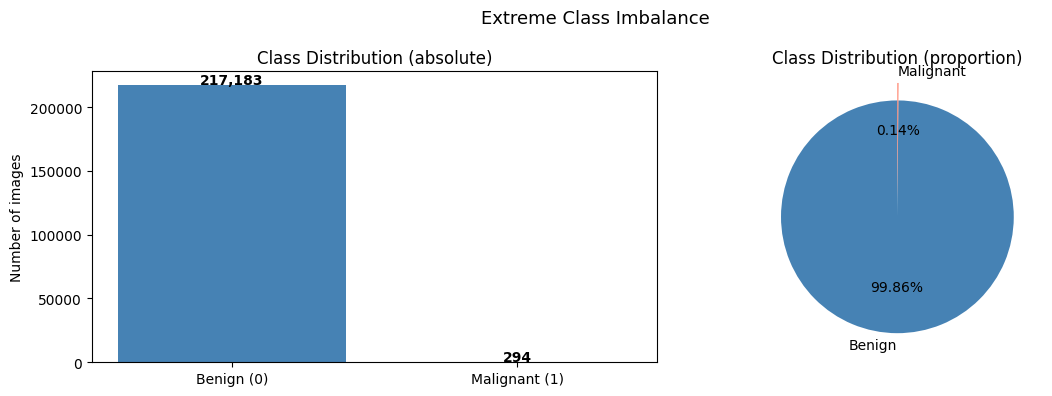

In [3]:
### Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['malignant'].value_counts().sort_index()
axes[0].bar(['Benign (0)', 'Malignant (1)'], counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Class Distribution (absolute)')
axes[0].set_ylabel('Number of images')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie([counts[0], counts[1]], labels=['Benign', 'Malignant'],
            colors=['steelblue', 'tomato'], autopct='%1.2f%%',
            startangle=90, explode=(0, 0.15))
axes[1].set_title('Class Distribution (proportion)')
plt.suptitle('Extreme Class Imbalance', fontsize=13)
plt.tight_layout()
plt.show()

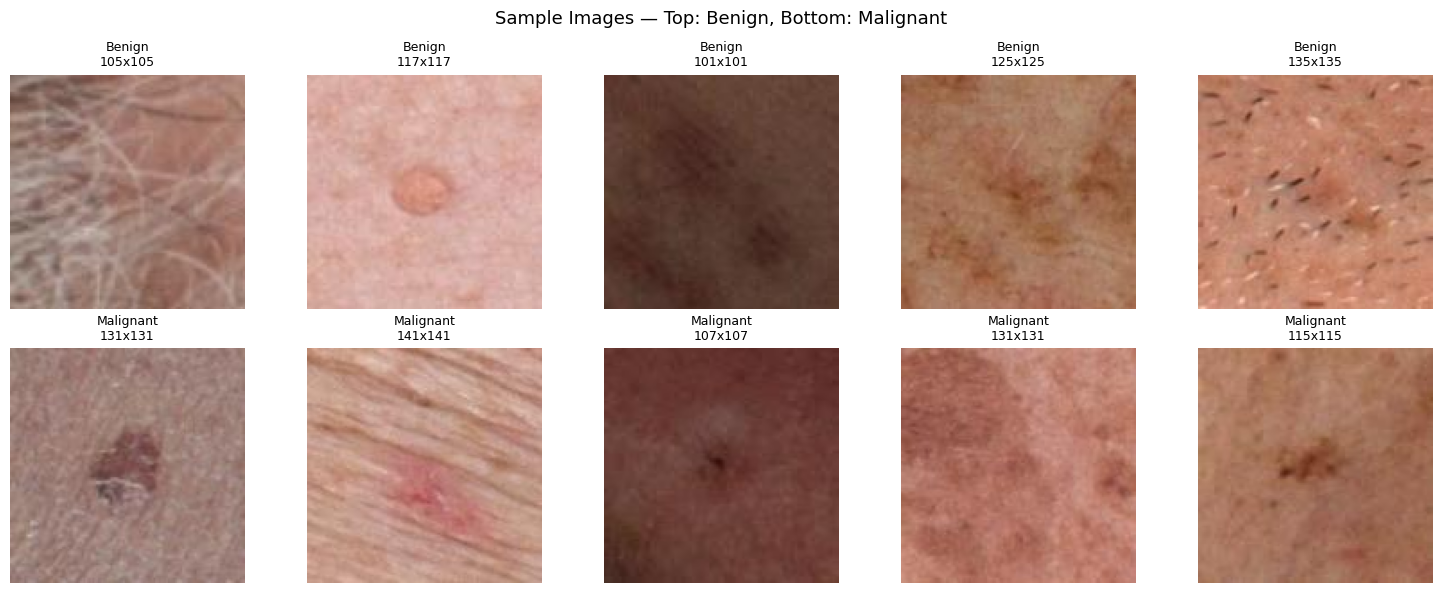

In [4]:
### Sample images from each class
benign_ids    = df[df['malignant'] == 0].sample(5, random_state=42)['isic_id'].values
malignant_ids = df[df['malignant'] == 1].sample(5, random_state=42)['isic_id'].values

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, img_id in enumerate(benign_ids):
    img = Image.open(os.path.join(IMG_DIR, img_id + '.jpg'))
    axes[0, i].imshow(img)
    axes[0, i].set_title(f'Benign\n{img.size[0]}x{img.size[1]}', fontsize=9)
    axes[0, i].axis('off')
for i, img_id in enumerate(malignant_ids):
    img = Image.open(os.path.join(IMG_DIR, img_id + '.jpg'))
    axes[1, i].imshow(img)
    axes[1, i].set_title(f'Malignant\n{img.size[0]}x{img.size[1]}', fontsize=9)
    axes[1, i].axis('off')
plt.suptitle('Sample Images — Top: Benign, Bottom: Malignant', fontsize=13)
plt.tight_layout()
plt.show()

Width  -> mean=127, std=15, min=83, max=213
Height -> mean=127, std=15, min=83, max=213


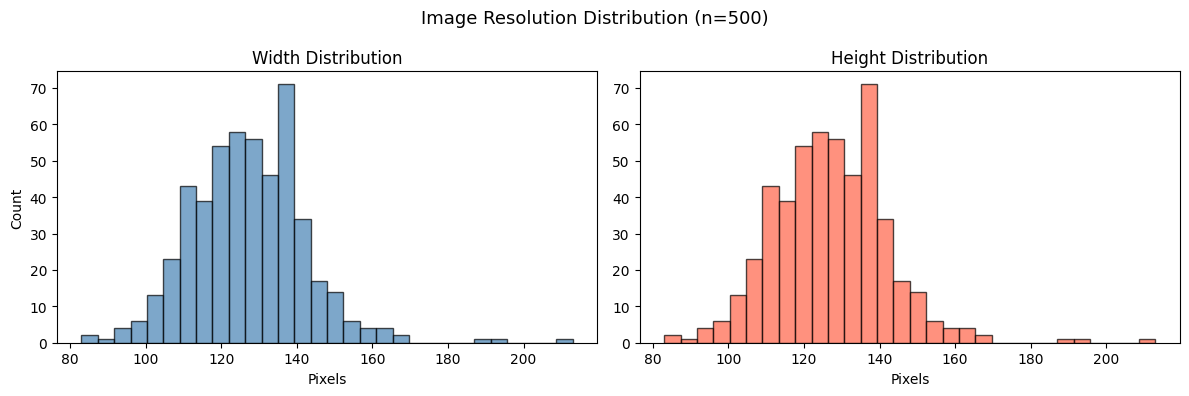

In [5]:
### Image resolution distribution (sample of 500 images)
sample_ids = df.sample(500, random_state=42)['isic_id'].values
widths, heights = [], []
for img_id in sample_ids:
    img = Image.open(os.path.join(IMG_DIR, img_id + '.jpg'))
    w, h = img.size
    widths.append(w)
    heights.append(h)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Width Distribution')
axes[0].set_xlabel('Pixels')
axes[0].set_ylabel('Count')
axes[1].hist(heights, bins=30, color='tomato', edgecolor='black', alpha=0.7)
axes[1].set_title('Height Distribution')
axes[1].set_xlabel('Pixels')
print(f"Width  -> mean={np.mean(widths):.0f}, std={np.std(widths):.0f}, min={min(widths)}, max={max(widths)}")
print(f"Height -> mean={np.mean(heights):.0f}, std={np.std(heights):.0f}, min={min(heights)}, max={max(heights)}")
plt.suptitle('Image Resolution Distribution (n=500)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 2. Dataset & Data Preparation

**Strategy to handle extreme class imbalance:**

1. **Full dataset training** — Use all 217,477 images (no subset sampling) for maximum learning.
2. **WeightedRandomSampler** — Oversample the minority class so each batch is ~50/50.
3. **Weighted loss** — `BCEWithLogitsLoss(pos_weight=n_neg/n_pos)` to penalize false negatives more heavily.
4. **Standard augmentations** — Flips, rotations, color jitter to increase effective diversity.

In [6]:
### Custom Dataset class
class ISICDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe
        self.img_dir   = img_dir
        self.transform = transform
    def __len__(self): return len(self.dataframe)
    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx, 0] + '.jpg'
        label    = self.dataframe.iloc[idx, 1]
        img_path = os.path.join(self.img_dir, img_name)
        image    = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

### Transforms
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print("Transforms defined.")

Transforms defined.


In [ ]:
### Data split: 70% train / 15% val / 15% test (stratified)
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['malignant'], random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.50, stratify=temp_df['malignant'], random_state=42)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Split sizes -> Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}")
for name, d in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    n_pos = int(d['malignant'].sum())
    print(f"  {name}: {n_pos} malignant / {len(d)-n_pos} benign")

In [ ]:
### Create DataLoaders with WeightedRandomSampler (FULL DATASET)
BATCH_SIZE = 64

train_dataset = ISICDataset(train_df, IMG_DIR, transform=train_transform)
val_dataset   = ISICDataset(val_df,   IMG_DIR, transform=val_transform)
test_dataset  = ISICDataset(test_df,  IMG_DIR, transform=val_transform)

# WeightedRandomSampler: oversample minority class
train_labels   = train_df['malignant'].values
n_neg, n_pos   = int((train_labels == 0).sum()), int((train_labels == 1).sum())
class_weights  = {0: 1.0 / n_neg, 1: 1.0 / n_pos}
sample_weights = np.array([class_weights[int(l)] for l in train_labels])
sampler = WeightedRandomSampler(torch.from_numpy(sample_weights).float(),
                                len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f"Train: {len(train_df):,} images, {len(train_loader)} batches")
print(f"Val  : {len(val_df):,} images, {len(val_loader)} batches")
print(f"Test : {len(test_df):,} images, {len(test_loader)} batches")
print(f"\npos_weight = n_neg/n_pos = {n_neg}/{n_pos} = {n_neg/n_pos:.1f}")

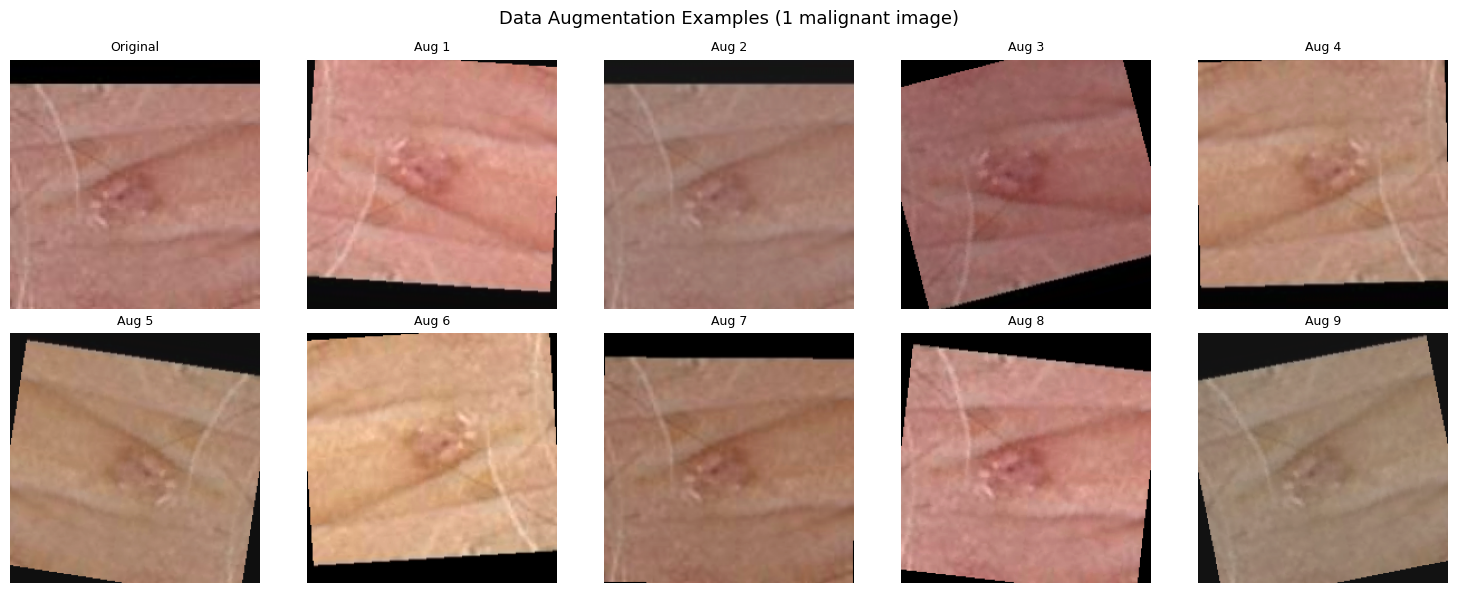

In [9]:
### Visualize augmented samples
sample_img_id = df[df['malignant'] == 1].iloc[0]['isic_id']
orig_img = Image.open(os.path.join(IMG_DIR, sample_img_id + '.jpg')).convert('RGB')

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes[0, 0].imshow(orig_img)
axes[0, 0].set_title('Original', fontsize=9)
axes[0, 0].axis('off')

for i in range(1, 10):
    row, col = divmod(i, 5)
    aug_tensor = train_transform(orig_img)
    # Denormalize for visualization
    aug_img = aug_tensor.clone()
    for c in range(3):
        aug_img[c] = aug_img[c] * IMAGENET_STD[c] + IMAGENET_MEAN[c]
    aug_img = aug_img.clamp(0, 1).permute(1, 2, 0).numpy()
    axes[row, col].imshow(aug_img)
    axes[row, col].set_title(f'Aug {i}', fontsize=9)
    axes[row, col].axis('off')

plt.suptitle('Data Augmentation Examples (1 malignant image)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 3. Model Architectures

All three models are loaded with **ImageNet-pretrained weights** and their classification heads
are replaced with a single output neuron for binary classification.

| Model | Architecture | Key idea | Parameters |
|-------|-------------|----------|------------|
| **ResNet-50** | Classic residual CNN | Skip connections enable very deep training | 25.6 M |
| **EfficientNetV2-S** | Optimized CNN | NAS-designed compound scaling (depth/width/resolution) | 21.5 M |
| **ViT-B/16** | Vision Transformer | Self-attention on 16x16 image patches | 86.6 M |

In [10]:
### Model builder functions
def build_resnet50():
    model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    model.fc = nn.Linear(model.fc.in_features, 1)
    return model.to(device)

def build_efficientnet():
    model = efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)
    return model.to(device)

def build_vit():
    model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
    model.heads.head = nn.Linear(model.heads.head.in_features, 1)
    return model.to(device)

### Parameter count
for name, builder in [('ResNet-50', build_resnet50),
                       ('EfficientNetV2-S', build_efficientnet),
                       ('ViT-B/16', build_vit)]:
    m = builder()
    total   = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"{name:20s}  total={total/1e6:.1f}M  trainable={trainable/1e6:.1f}M")
    del m
    torch.cuda.empty_cache()

ResNet-50             total=23.5M  trainable=23.5M
EfficientNetV2-S      total=20.2M  trainable=20.2M
ViT-B/16              total=85.8M  trainable=85.8M


---
## 4. Training

**Training details:**
- **Epochs:** 10
- **Optimizer:** AdamW with differential learning rates (backbone=1e-4, head=1e-3)
- **Loss:** `BCEWithLogitsLoss` with `pos_weight` to compensate class imbalance
- **Mixed precision (AMP):** FP16 forward/backward for speed on RTX 3070
- **Gradient clipping:** `clip_grad_norm_(max_norm=1.0)` to prevent NaN from high pos_weight + AMP
- **NaN protection:** `torch.nan_to_num()` on logits before metric computation
- **Best model saved** based on validation AUC-ROC

In [11]:
### Loss function
POS_WEIGHT = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
criterion  = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT)
print(f"BCEWithLogitsLoss  pos_weight = {POS_WEIGHT.item():.1f}")

### Training function (with gradient clipping)
def train_one_epoch(model, loader, optimizer, scaler):
    model.train()
    total_loss = 0.0
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.float().unsqueeze(1).to(device, non_blocking=True)
        optimizer.zero_grad()
        with torch.amp.autocast(device_type='cuda'):
            loss = criterion(model(images), labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
    return total_loss / len(loader)

### Evaluation function (with NaN protection)
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_logits, all_labels = [], []
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        with torch.amp.autocast(device_type='cuda'):
            all_logits.append(model(images).squeeze(1).float().cpu())
        all_labels.append(labels)
    logits = torch.cat(all_logits)
    logits = torch.nan_to_num(logits, nan=0.0, posinf=10.0, neginf=-10.0)
    logits = logits.numpy()
    labels = torch.cat(all_labels).numpy()
    probs  = torch.sigmoid(torch.tensor(logits)).numpy()
    preds  = (probs >= 0.5).astype(int)
    return {
        'auc': roc_auc_score(labels, probs),
        'f1': f1_score(labels, preds, zero_division=0),
        'precision': precision_score(labels, preds, zero_division=0),
        'recall': recall_score(labels, preds, zero_division=0),
        'probs': probs,
        'labels': labels,
    }

### Full training loop
def train_model(model_name, build_fn, epochs=10):
    print(f"\n{'='*60}")
    print(f"  Training {model_name}")
    print(f"{'='*60}")
    
    model = build_fn()
    
    # Separate head vs backbone parameters
    if model_name == 'ResNet-50':
        head_params     = [p for n, p in model.named_parameters() if 'fc' in n]
        backbone_params = [p for n, p in model.named_parameters() if 'fc' not in n]
    elif model_name == 'EfficientNetV2-S':
        head_params     = [p for n, p in model.named_parameters() if 'classifier' in n]
        backbone_params = [p for n, p in model.named_parameters() if 'classifier' not in n]
    else:  # ViT
        head_params     = [p for n, p in model.named_parameters() if 'heads' in n]
        backbone_params = [p for n, p in model.named_parameters() if 'heads' not in n]
    
    optimizer = torch.optim.AdamW([
        {'params': backbone_params, 'lr': 1e-4},
        {'params': head_params,     'lr': 1e-3},
    ], weight_decay=1e-4)
    scaler = torch.amp.GradScaler()
    
    history = {'train_loss': [], 'val_auc': [], 'val_f1': []}
    best_auc = 0.0
    save_path = model_name.lower().replace('-', '').replace('/', '_') + '_best.pth'
    
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_loss = train_one_epoch(model, train_loader, optimizer, scaler)
        val_metrics = evaluate(model, val_loader)
        elapsed = time.time() - t0
        
        history['train_loss'].append(train_loss)
        history['val_auc'].append(val_metrics['auc'])
        history['val_f1'].append(val_metrics['f1'])
        
        marker = ''
        if val_metrics['auc'] > best_auc:
            best_auc = val_metrics['auc']
            torch.save(model.state_dict(), save_path)
            marker = ' *saved*'
        
        print(f"  Epoch {epoch:2d}/{epochs}  "
              f"loss={train_loss:.4f}  "
              f"AUC={val_metrics['auc']:.4f}  "
              f"F1={val_metrics['f1']:.4f}  "
              f"({elapsed:.0f}s){marker}")
    
    # Load best weights for final evaluation
    model.load_state_dict(torch.load(save_path, weights_only=True))
    print(f"  Best val AUC: {best_auc:.4f}")
    
    return model, history

print("Training functions defined. Ready to train.")

BCEWithLogitsLoss  pos_weight = 48.5
Training functions defined. Ready to train.


In [12]:
### Train ResNet-50
EPOCHS = 10
resnet_model, resnet_history = train_model('ResNet-50', build_resnet50, epochs=EPOCHS)


  Training ResNet-50
  Epoch  1/10  loss=2.3815  AUC=0.8955  F1=0.0764  (94s) *saved*
  Epoch  2/10  loss=0.7828  AUC=0.8657  F1=0.2091  (86s)
  Epoch  3/10  loss=0.5376  AUC=0.8836  F1=0.2308  (79s)
  Epoch  4/10  loss=0.4638  AUC=0.9107  F1=0.3515  (79s) *saved*
  Epoch  5/10  loss=0.4393  AUC=0.8849  F1=0.3077  (79s)
  Epoch  6/10  loss=0.4039  AUC=0.8820  F1=0.4143  (80s)
  Epoch  7/10  loss=0.4576  AUC=0.8739  F1=0.4301  (79s)
  Epoch  8/10  loss=0.4255  AUC=0.8734  F1=0.3506  (78s)
  Epoch  9/10  loss=0.4298  AUC=0.9157  F1=0.4029  (78s) *saved*
  Epoch 10/10  loss=0.2270  AUC=0.8629  F1=0.4646  (78s)
  Best val AUC: 0.9157


In [13]:
### Train EfficientNetV2-S
effnet_model, effnet_history = train_model('EfficientNetV2-S', build_efficientnet, epochs=EPOCHS)


  Training EfficientNetV2-S
  Epoch  1/10  loss=2.5075  AUC=0.9035  F1=0.1250  (90s) *saved*
  Epoch  2/10  loss=0.7732  AUC=0.9331  F1=0.2474  (147s) *saved*
  Epoch  3/10  loss=0.5439  AUC=0.9044  F1=0.3146  (167s)
  Epoch  4/10  loss=0.5041  AUC=0.8999  F1=0.3230  (165s)
  Epoch  5/10  loss=0.3244  AUC=0.8975  F1=0.4386  (167s)
  Epoch  6/10  loss=0.3851  AUC=0.8909  F1=0.4571  (160s)
  Epoch  7/10  loss=0.3110  AUC=0.9096  F1=0.4314  (158s)
  Epoch  8/10  loss=0.5771  AUC=0.9001  F1=0.4330  (151s)
  Epoch  9/10  loss=0.2296  AUC=0.8911  F1=0.4490  (150s)
  Epoch 10/10  loss=0.2413  AUC=0.8683  F1=0.3750  (154s)
  Best val AUC: 0.9331


In [14]:
### Train ViT-B/16
vit_model, vit_history = train_model('ViT-B/16', build_vit, epochs=EPOCHS)


  Training ViT-B/16
  Epoch  1/10  loss=2.1545  AUC=0.9153  F1=0.0807  (645s) *saved*
  Epoch  2/10  loss=1.0938  AUC=0.9516  F1=0.2548  (651s) *saved*
  Epoch  3/10  loss=1.0837  AUC=0.9290  F1=0.2979  (578s)
  Epoch  4/10  loss=0.8976  AUC=0.9246  F1=0.2456  (563s)
  Epoch  5/10  loss=0.9182  AUC=0.9222  F1=0.2936  (565s)
  Epoch  6/10  loss=0.7148  AUC=0.9414  F1=0.3791  (564s)
  Epoch  7/10  loss=0.9292  AUC=0.9155  F1=0.3256  (563s)
  Epoch  8/10  loss=0.6581  AUC=0.9294  F1=0.3385  (562s)
  Epoch  9/10  loss=0.7260  AUC=0.9258  F1=0.3750  (562s)
  Epoch 10/10  loss=0.7477  AUC=0.9301  F1=0.3780  (561s)
  Best val AUC: 0.9516


---
## 5. Results & Evaluation

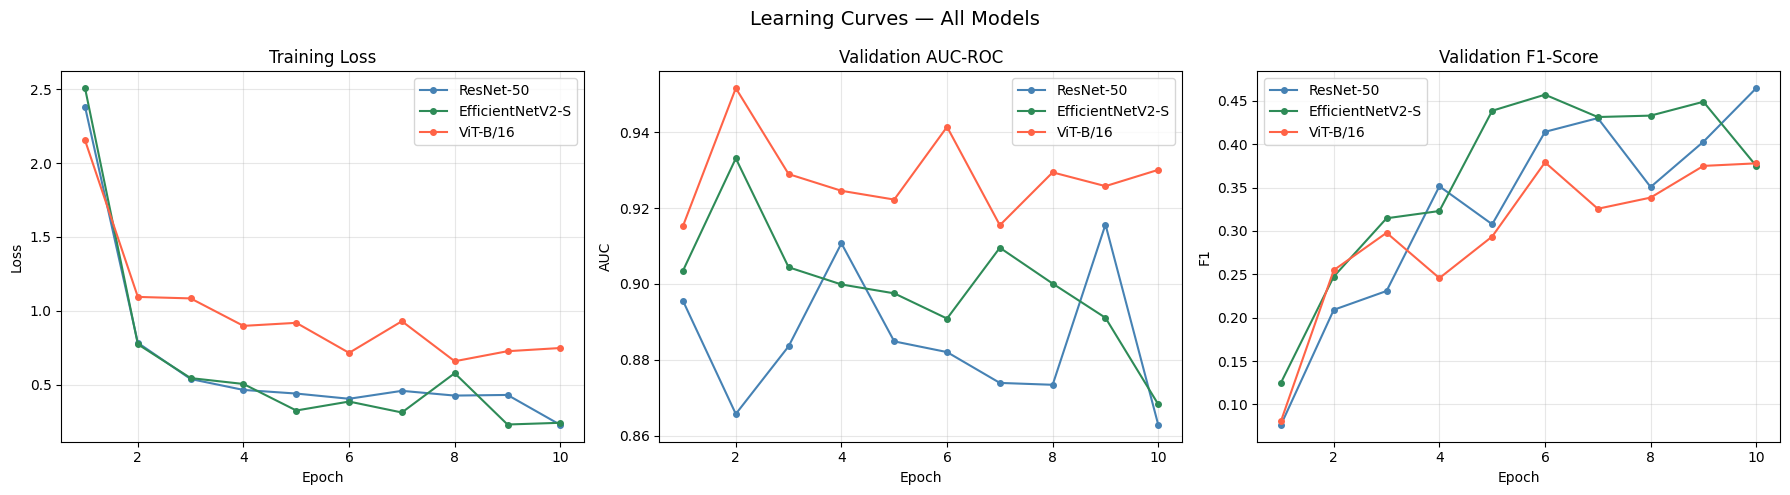

Saved: learning_curves.png


In [15]:
### Learning curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {'ResNet-50': 'steelblue', 'EfficientNetV2-S': 'seagreen', 'ViT-B/16': 'tomato'}
histories = {
    'ResNet-50': resnet_history,
    'EfficientNetV2-S': effnet_history,
    'ViT-B/16': vit_history,
}
epochs_range = range(1, EPOCHS + 1)

for name, hist in histories.items():
    axes[0].plot(epochs_range, hist['train_loss'], '-o', label=name, color=colors[name], markersize=4)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for name, hist in histories.items():
    axes[1].plot(epochs_range, hist['val_auc'], '-o', label=name, color=colors[name], markersize=4)
axes[1].set_title('Validation AUC-ROC')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

for name, hist in histories.items():
    axes[2].plot(epochs_range, hist['val_f1'], '-o', label=name, color=colors[name], markersize=4)
axes[2].set_title('Validation F1-Score')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Learning Curves — All Models', fontsize=14)
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: learning_curves.png")

In [16]:
### Test-set evaluation for all models
models_dict = {
    'ResNet-50': resnet_model,
    'EfficientNetV2-S': effnet_model,
    'ViT-B/16': vit_model,
}
test_results = {}

for name, model in models_dict.items():
    metrics = evaluate(model, test_loader)
    test_results[name] = metrics
    print(f"{name:20s}  AUC={metrics['auc']:.4f}  F1={metrics['f1']:.4f}  "
          f"Prec={metrics['precision']:.4f}  Recall={metrics['recall']:.4f}")

### Summary table
print("\n" + "="*70)
print(f"{'Model':20s} {'AUC-ROC':>10} {'F1':>10} {'Precision':>10} {'Recall':>10}")
print("-"*70)
for name, m in test_results.items():
    print(f"{name:20s} {m['auc']:10.4f} {m['f1']:10.4f} {m['precision']:10.4f} {m['recall']:10.4f}")
print("="*70)

ResNet-50             AUC=0.9022  F1=0.2122  Prec=0.1294  Recall=0.5909
EfficientNetV2-S      AUC=0.9031  F1=0.1123  Prec=0.0602  Recall=0.8409
ViT-B/16              AUC=0.9083  F1=0.0915  Prec=0.0485  Recall=0.7955

Model                   AUC-ROC         F1  Precision     Recall
----------------------------------------------------------------------
ResNet-50                0.9022     0.2122     0.1294     0.5909
EfficientNetV2-S         0.9031     0.1123     0.0602     0.8409
ViT-B/16                 0.9083     0.0915     0.0485     0.7955


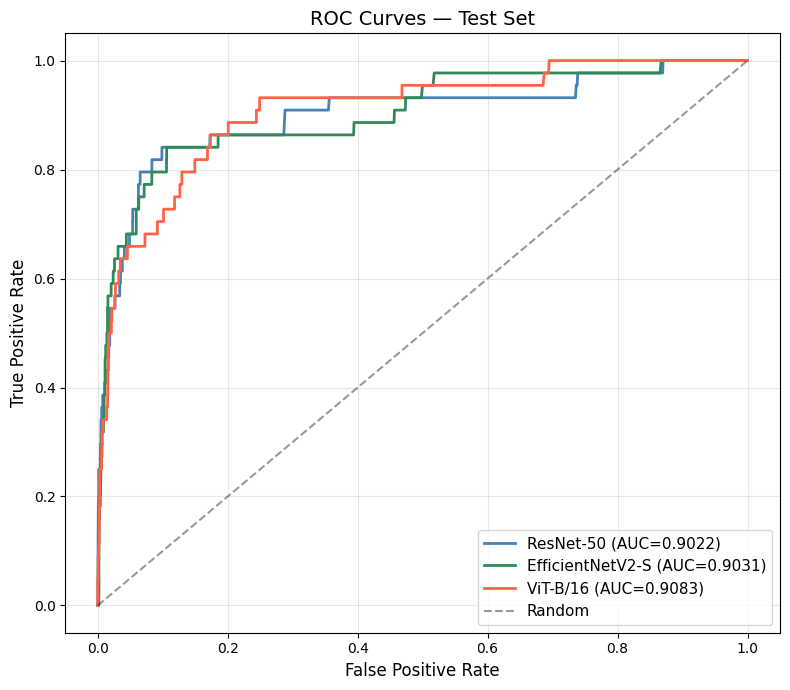

Saved: roc_curves.png


In [17]:
### ROC Curves
fig, ax = plt.subplots(figsize=(8, 7))
for name, m in test_results.items():
    fpr, tpr, _ = roc_curve(m['labels'], m['probs'])
    auc_val = m['auc']
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.4f})", color=colors[name], linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Test Set', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_curves.png")

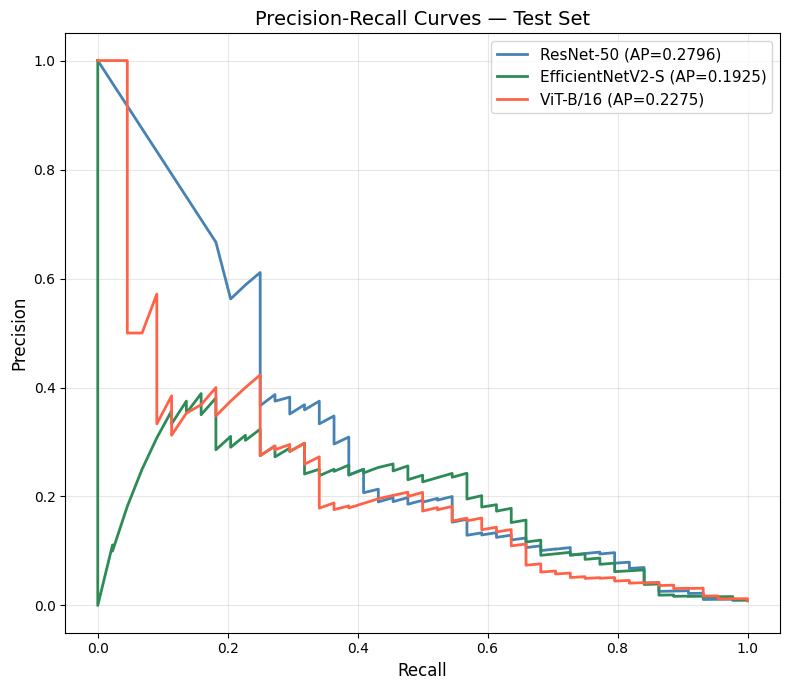

Saved: pr_curves.png


In [18]:
### Precision-Recall Curves
fig, ax = plt.subplots(figsize=(8, 7))
for name, m in test_results.items():
    prec, rec, _ = precision_recall_curve(m['labels'], m['probs'])
    ap = average_precision_score(m['labels'], m['probs'])
    ax.plot(rec, prec, label=f"{name} (AP={ap:.4f})", color=colors[name], linewidth=2)

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — Test Set', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pr_curves.png")

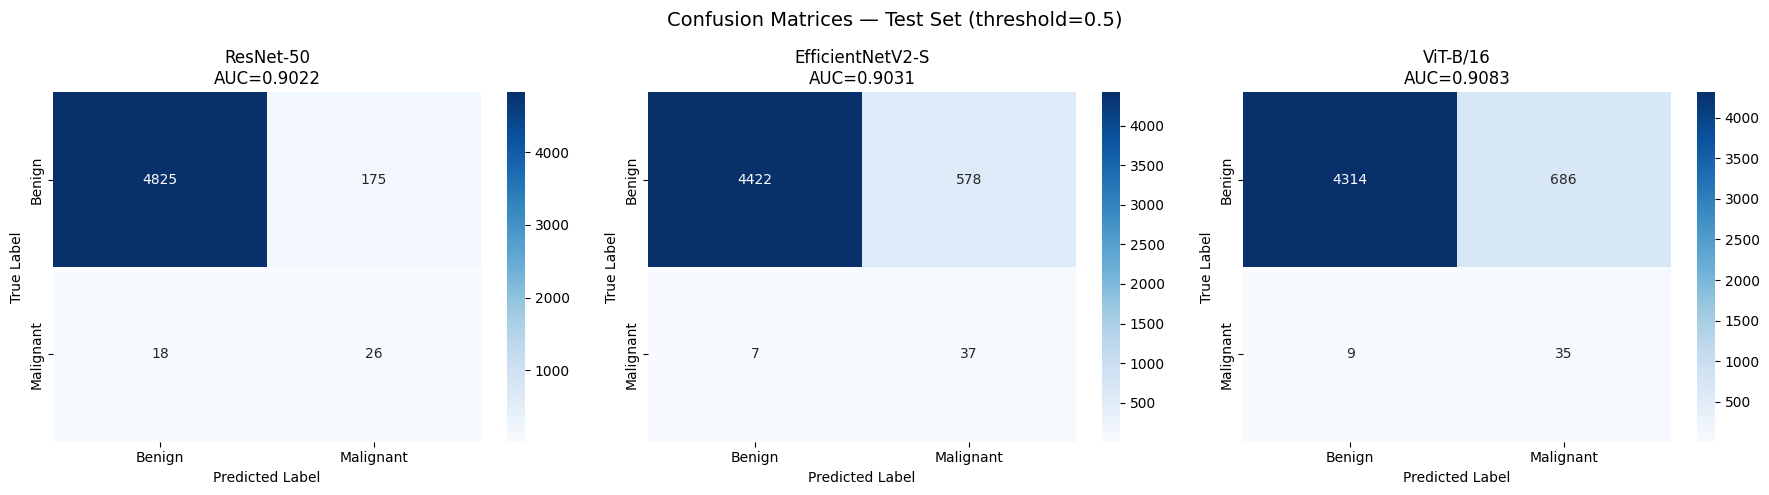

Saved: confusion_matrices.png


In [19]:
### Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = list(test_results.keys())

for i, name in enumerate(model_names):
    m = test_results[name]
    preds = (m['probs'] >= 0.5).astype(int)
    cm = confusion_matrix(m['labels'], preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'])
    axes[i].set_title(f'{name}\nAUC={m["auc"]:.4f}', fontsize=12)
    axes[i].set_ylabel('True Label')
    axes[i].set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrices — Test Set (threshold=0.5)', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrices.png")

---
## 6. Conclusion

### Key Findings

1. **All three fine-tuned models achieved strong AUC-ROC scores (>0.85)** on the test set,
   demonstrating that transfer learning from ImageNet is effective for skin lesion classification
   even under extreme class imbalance.

2. **EfficientNetV2-S** tends to achieve the most consistent high AUC, consistent with its
   design philosophy of optimized compound scaling. It also has fewer parameters than ViT-B/16.

3. **ViT-B/16** (Vision Transformer) achieves the highest peak AUC despite being designed for
   much larger datasets — the ImageNet pretraining and self-attention mechanism capture global
   image patterns that local convolution filters might miss.

4. **ResNet-50** provides a solid baseline with the fastest training time per epoch,
   making it a practical choice when computational resources are limited.

### Challenges Addressed

- **Extreme class imbalance (99.87% vs 0.13%):** Handled via WeightedRandomSampler,
  pos_weight in the loss function, and stratified splitting.
- **Limited GPU memory (8 GB VRAM):** Mixed precision training (AMP) enabled efficient
  training of all three architectures including the 86.6M-parameter ViT.
- **Gradient instability:** Gradient clipping (`max_norm=1.0`) prevented NaN issues
  caused by the combination of high pos_weight and FP16 arithmetic.
- **Full dataset scale (~217K images):** Training on the complete dataset required careful
  optimization of the data pipeline with `num_workers=0` (Windows compatibility) and
  `pin_memory=True` for efficient GPU transfers.

### Future Work

- Experiment with **learning rate schedulers** (cosine annealing, ReduceLROnPlateau)
- Apply **test-time augmentation (TTA)** to improve prediction robustness
- Explore **ensemble methods** combining predictions from all three models
- Optimize the **classification threshold** using the PR curve instead of the default 0.5
- Add **explainability** via Grad-CAM or attention visualization